# Required Libraries

In [55]:
import time
import threading
import matplotlib.pyplot as plt

# Constants representing CAN bus message properties

In [56]:
SOF = 1  # Start of Frame
EOF = 1  # End of Frame
CRC = 0  # Cyclic Redundancy Check (always 0 for this project)
ACK = 0  # Acknowledge (always 0 for this project)
CONTROL = 1  # Control field for normal ECUs
ADV_CONTROL = 0  # Control field for adversary ECUs
RTR_REQUEST_DATA = 0  # Request data from another ECU
RTR_SEND_DATA = 1  # Send data to another ECU

# ECU error states

In [57]:
ERROR_ACTIVE = "ErrorActive"
ERROR_PASSIVE = "ErrorPassive"
BUSS_OFF = "BusOff"

# ECU roles

In [58]:
VICTIM_ECU = "Victim   "
NORMAL_ECU = "Normal   "
ADVERSARY_ECU = "Adversary"

# Global flag to control thread execution

In [59]:
running = True

# Class representing a simplified CAN packet

In [60]:
class Packet:
    def __init__(self, ecu_id, id, rtr, data, control=CONTROL, sof=SOF, ack=ACK, eof=EOF, crc=CRC):
        """
        Initialize a CAN bus packet.

        Parameters:
        - ecu_id: Identifier of the sending ECU.
        - id: Packet ID (lower value has higher priority).
        - rtr: Remote Transmission Request (0 = request, 1 = send data).
        - data: Payload data of the packet.
        - control: Control field (1 for normal ECUs, 0 for adversaries).
        - sof: Start of Frame (always 1 for this project).
        - ack: Acknowledge field (always 0 for this project).
        - eof: End of Frame (always 1 for this project).
        - crc: Cyclic Redundancy Check (always 0 for this project).
        """
        self.ecu_id = ecu_id
        self.sof = sof
        self.id = id
        self.rtr = rtr
        self.control = control
        self.data = data
        self.crc = crc
        self.ack = ack
        self.eof = eof

    def to_Array(self):
        """Return the packet as a list of its fields."""
        return [self.sof, self.id, self.rtr, self.control, self.data, self.crc, self.ack, self.eof]

    def get_EcuId(self):
        """Return the ECU ID of the sender."""
        return self.ecu_id

    def get_Id(self):
        """Return the packet ID."""
        return self.id

    def get_Control(self):
        """Return the control field of the packet."""
        return self.control

    def get_Data(self):
        """Return the data payload of the packet."""
        return self.data

# Class representing a simplified ECU (Electronic Control Unit)

In [61]:
class ECU:
    def __init__(self, ecu_id, attack_mode=NORMAL_ECU, adv_target=-1):
        """
        Initialize an ECU object.

        Parameters:
        - ecu_id: Identifier of the ECU.
        - attack_mode: Role of the ECU (Normal, Victim, or Adversary).
        - adv_target: Target ECU ID for adversary attacks (-1 if not adversary).
        """
        self.attack_mode = attack_mode
        self.adv_target = adv_target
        self.ecu_id = ecu_id
        self.tec = 0  # Transmit Error Counter
        self.rec = 0  # Receive Error Counter
        self.passive_flag = False  # Indicates if retransmission is required in Error Passive mode
        self.active_flag = False  # Indicates if retransmission is required in Error Active mode
        self.retransmission_needed = False
        self.retransmission_delay = 0.1
        self.status = ERROR_ACTIVE  # Default status is Error Active
        self.tec_history = [0]  # History of TEC values
        self.tec_timestamp = [time.time()]  # Timestamps for TEC history
        self.sent_packets = {}  # Stores sent packets indexed by their ID

    def ecu_status_check(self):
        """
        Check and update the status of the ECU based on TEC and REC values.
        """
        # Error Active
        if self.tec <= 127 and self.rec <= 127:
            self.status = ERROR_ACTIVE
        # Error Passive
        elif 127 < self.tec <= 255 or 127 < self.rec <= 255:
            self.status = ERROR_PASSIVE
            self.retransmission_delay = 0.5
        # Bus-Off
        elif self.tec > 255:
            self.status = BUSS_OFF

    def send_packet(self, packet_id, data, canbus, retransmission=False):
        """
        Send a packet to the CAN bus.

        Parameters:
        - packet_id: ID of the packet to be sent.
        - data: Payload of the packet.
        - canbus: CANBus object representing the network.
        - retransmission: True if the packet is a retransmission, False otherwise.
        """
        # Create an appropriate packet based on the attack_mode of the ECU
        if self.attack_mode == ADVERSARY_ECU:
            packet = Packet(self.ecu_id, packet_id, RTR_SEND_DATA, data, control=ADV_CONTROL)
        else:
            packet = Packet(self.ecu_id, packet_id, RTR_SEND_DATA, data)

        # Stores the sent packet for later comparison (if it's not a retransmission)
        if not retransmission:
            self.sent_packets[packet_id] = (data, packet)

        # Add the packet to the CAN bus log --> simulate packets sending
        with canbus.lock:
            canbus.packet_log.append(packet)
            print(f"{'Retrasmission | ' if retransmission else ''}|  [{self.attack_mode}] | ECU {self.ecu_id} sent packet: ID={packet.get_Id()} PACKET={packet.to_Array()} |")

    def check_duplicate_ids(self, packet_id, canbus):
        """
        Check the CAN bus log for duplicate packet IDs and set retransmission flags if needed.

        Parameters:
        - packet_id: ID of the packet to check for duplicates.
        - canbus: CANBus object representing the network.
        """
        with canbus.lock:
            # Finds duplicated packet sent onto the CAN bus at the same moment
            duplicates = [msg for msg in canbus.packet_log if msg.get_Id() == packet_id and msg.get_EcuId() != self.ecu_id]

            if len(duplicates) > 0:
                # Compare duplicates
                for duplicate in duplicates:

                    original_data, original_packet = self.sent_packets[packet_id]
                    # Compare the packets array for checking mismatches
                    if duplicate.to_Array() != original_packet.to_Array():

                        self.retransmission_needed = True

                        if self.status == ERROR_ACTIVE:

                            if self.attack_mode == ADVERSARY_ECU:
                                # Find the victim ecu in case self is an adversary ECU
                                victim_ecu = next((ecu for ecu in canbus.ecus if ecu.ecu_id == self.adv_target), None)
                                # Set the active flag of the adversary to True only if also the victim is in ERROR_ACTIVE
                                if victim_ecu.status == ERROR_ACTIVE:
                                    self.active_flag = True

                            # Case ECUs are not adversaries
                            else:
                                self.active_flag = True

                        elif self.status == ERROR_PASSIVE:

                            if self.attack_mode != ADVERSARY_ECU:
                                self.passive_flag = True

            else:
                self.retransmission_needed = False

    def tec_rec_check(self, packet_id, canbus):
        """
        Update the TEC and REC counters based on the CAN bus communication outcomes.

        Parameters:
        - packet_id: ID of the packet being checked.
        - canbus: CANBus object representing the network.
        """
        with canbus.lock:

            self.ecu_status_check()
            duplicates = [msg for msg in canbus.packet_log if msg.get_Id() == packet_id and msg.get_EcuId() != self.ecu_id]

            if len(duplicates) > 0:
                # Compare duplicates
                for duplicate in duplicates:

                    original_data, original_packet = self.sent_packets[packet_id]
                    # Compare the packets array for checking mismatches
                    if duplicate.to_Array() != original_packet.to_Array():

                        # Checks the ECU status and if there are some active flags
                        if self.status == ERROR_ACTIVE and self.active_flag:

                            self.tec += 8
                            self.tec_history.append(self.tec)
                            self.tec_timestamp.append(time.time())
                            self.rec += 8

                        elif self.status == ERROR_PASSIVE and self.passive_flag:

                            self.tec += 8
                            self.tec_history.append(self.tec)
                            self.tec_timestamp.append(time.time())
                            self.tec -= 1
                            self.tec_history.append(self.tec)
                            self.tec_timestamp.append(time.time())
                            self.rec += 8
                            self.rec -= 1

                        if self.attack_mode == ADVERSARY_ECU:
                            victim_ecu = next((ecu for ecu in canbus.ecus if ecu.ecu_id == self.adv_target), None)
                            if victim_ecu.passive_flag:

                                self.tec -= 1
                                self.tec_history.append(self.tec)
                                self.tec_timestamp.append(time.time())
                                self.rec -= 1

            self.ecu_status_check()
            print(f"{self.attack_mode} -> tec: {self.tec} rec: {self.rec} activeFlag: {self.active_flag} passiveFlag: {self.passive_flag} {self.status}")
            self.active_flag = False
            self.passive_flag = False

# Class representing a simplified CAN bus

In [62]:
class CANBus:
    def __init__(self):
        # List of connected ECUs
        self.ecus = []
        # Log of all packets on the bus (it will be cleared at each iteraction)
        self.packet_log = []
         # Lock for thread-safe access to the log
        self.lock = threading.Lock()

    def connect_ecu(self, ecu):
        """
            Connect an ECU to the CAN bus.
            An ECU in order to send packets has to be connected to the CAN bus
        """
        if ecu not in self.ecus:
            self.ecus.append(ecu)
            print(f"The ECU {ecu.ecu_id} has been connected to the CAN bus")
        else:
            print(f"The ECU {ecu.ecu_id} is already connected")

    def disconnect_ecu(self, ecu):
        """
            Disconnect an ECU from the CAN bus.
        """
        if ecu in self.ecus:
            self.ecus.remove(ecu)
            print(f"The ECU {ecu.ecu_id} has been disconnected from the CAN bus")
        else:
            print(f"The ECU {ecu.ecu_id} is not connected")

In [63]:
def run_ecu(ecu, packet_id, data, canbus, barrier):
    """
    Simulate the behavior of an ECU, including sending packets and handling errors
    throug ECU functions.

    Parameters:
    - ecu: The ECU object representing the node in the CAN bus.
    - packet_id: The ID of the packet to be sent by the ECU.
    - data: The data payload to be sent in the packet.
    - canbus: The shared CAN bus object connecting all ECUs.
    - barrier: A threading barrier used to synchronize ECUs' actions.
    """
    global running
    while running and ecu in canbus.ecus and len(canbus.ecus) > 1:
        # Clear the CAN bus packet log to ensure a clean state for the next round of communication.
        canbus.packet_log.clear()

        # Check the status of the ECU
        ecu.ecu_status_check()
        # If the ECU is in a bus-off state --> disconnect it from the can bus
        if ecu.status == BUSS_OFF:
            with canbus.lock:
                canbus.disconnect_ecu(ecu)
            running = False # Stop all ECU threads.
            break

        # Synchronize with other ECUs before sending packets.
        try:
            barrier.wait(timeout=1)  # Wait for all threads to reach this point or timeout after 1 second.
        except threading.BrokenBarrierError:
            break # If the barrier is broken (e.g., one thread exits), stop execution.

        # If a retransmission is required, resend the previously sent packet.
        if ecu.retransmission_needed:
            ecu.send_packet(packet_id, ecu.sent_packets[packet_id][1].get_Data(), canbus, retransmission=True)
        else:
            # Otherwise, send a new packet with the specified data.
            ecu.send_packet(packet_id, data, canbus)

        # Synchronize again after sending packets to allow other ECUs to react.
        try:
            barrier.wait(timeout=1)
        except threading.BrokenBarrierError:
            break

        # Check the CAN bus log for duplicate packet IDs and handle retransmissions or error flags as needed.
        ecu.check_duplicate_ids(packet_id, canbus)

        # Synchronize again after sending packets to allow other ECUs to react.
        try:
            barrier.wait(timeout=1)
        except threading.BrokenBarrierError:
            break

        # Update the ECU's TEC and REC counters based on communication results.
        ecu.tec_rec_check(packet_id, canbus)

        # Wait for the retransmission delay before the next iteration.
        time.sleep(ecu.retransmission_delay)
        print("----------------------------------------------------------------")

In [64]:
def plot_tec_history(*ecus):
    """
        Plot TEC history of the ECUs passed as parameters
        Parameters:
        - ecus: The ECUs objects.
    """
    for ecu in ecus:
        # Calcola l'asse x come differenza di tempo rispetto al primo timestamp
        x_axis = [t - ecu.tec_timestamp[0] for t in ecu.tec_timestamp]
        if ecu.attack_mode == ADVERSARY_ECU:
            plt.plot(x_axis, ecu.tec_history, label=f"ECU {ecu.ecu_id} ({ecu.attack_mode})", linestyle='--')
        else:
            plt.plot(x_axis, ecu.tec_history, label=f"ECU {ecu.ecu_id} ({ecu.attack_mode})")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Transmit Error Counter (TEC)")
    plt.title("TEC Evolution of ECUs")
    plt.legend()
    plt.grid()
    plt.show()

# Create the CAN bus and ECU objects

The ECU 1 has been connected to the CAN bus
The ECU 2 has been connected to the CAN bus
|  [Adversary] | ECU 2 sent packet: ID=100 PACKET=[1, 100, 1, 0, [0, 0, 1], 0, 0, 1] |
|  [Normal   ] | ECU 1 sent packet: ID=100 PACKET=[1, 100, 1, 1, [1, 0, 1], 0, 0, 1] |
Adversary -> tec: 8 rec: 8 activeFlag: True passiveFlag: False ErrorActive
Normal    -> tec: 8 rec: 8 activeFlag: True passiveFlag: False ErrorActive
----------------------------------------------------------------
----------------------------------------------------------------
Retrasmission | |  [Adversary] | ECU 2 sent packet: ID=100 PACKET=[1, 100, 1, 0, [0, 0, 1], 0, 0, 1] |
Retrasmission | |  [Normal   ] | ECU 1 sent packet: ID=100 PACKET=[1, 100, 1, 1, [1, 0, 1], 0, 0, 1] |
Adversary -> tec: 16 rec: 16 activeFlag: True passiveFlag: False ErrorActive
Normal    -> tec: 16 rec: 16 activeFlag: True passiveFlag: False ErrorActive
----------------------------------------------------------------
---------------------------------

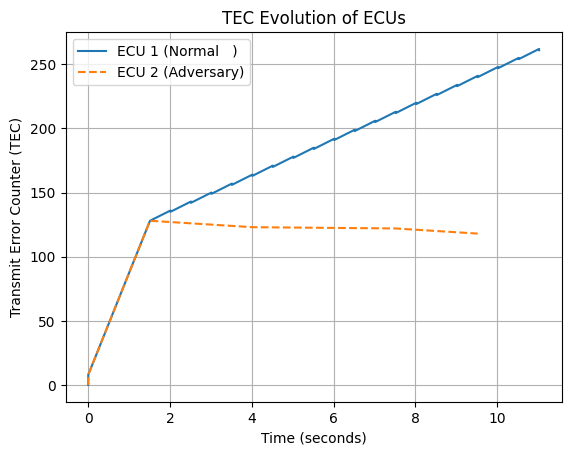

In [65]:
canbus = CANBus()
ecu1 = ECU(1)
ecu2 = ECU(2, attack_mode=ADVERSARY_ECU, adv_target=1)
# Connect the ECUs to the CAN bus
canbus.connect_ecu(ecu1)
canbus.connect_ecu(ecu2)
# Create a barrier for synchronizing two thread
barrier = threading.Barrier(2)
# Start two thread for the two ECUs
thread1 = threading.Thread(target=run_ecu, args=(ecu1, 100, [1, 0, 1], canbus, barrier))
thread2 = threading.Thread(target=run_ecu, args=(ecu2, 100, [0, 0, 1], canbus, barrier))

thread1.start()
thread2.start()

thread1.join()
thread2.join()
# Plot the final TEC history graph
plot_tec_history(ecu1, ecu2)